<a href="https://colab.research.google.com/github/GuilhermeBrognoli/Analise-de-credito-ml/blob/main/credit_ml_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de Machine Learning para Análise de Crédito
**Baseado no artigo:**  
*Desenvolvimento e Comparação de Modelos de Machine Learning para Definição de Limite de Crédito em Operações Comerciais*

**Dataset:** Default of Credit Card Clients — UCI ML Repository (30.000 clientes)  
**Variável-alvo:** `default` — inadimplência no mês seguinte (1 = inadimplente, 0 = adimplente)

## 1. Dependências
> Execute a célula abaixo para instalar as bibliotecas necessárias.

In [ ]:
!pip install imbalanced-learn openpyxl -q

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Carregamento dos Dados
Tenta baixar o dataset original do UCI. Caso não haja conexão, gera dados sintéticos com a mesma estrutura.

In [ ]:
URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00350/default%20of%20credit%20card%20clients.xls"
)

try:
    df = pd.read_excel(URL, header=1)
    print(f"Dataset carregado: {df.shape[0]} clientes | {df.shape[1]} colunas")
except Exception:
    print("[AVISO] Não foi possível baixar o dataset. Gerando dados sintéticos...")
    rng = np.random.default_rng(42)
    n = 30_000
    df = pd.DataFrame({
        "ID": range(1, n + 1),
        "limite_credito": rng.integers(10_000, 800_001, n),
        "sexo": rng.choice([1, 2], n),
        "escolaridade": rng.choice([1, 2, 3, 4], n),
        "estado_civil": rng.choice([1, 2, 3], n),
        "idade": rng.integers(21, 75, n),
        **{f"atraso_mes{{i+1}}": rng.choice([-2, -1, 0, 1, 2, 3], n) for i in range(6)},
        **{f"fatura_mes{{i}}": rng.integers(0, 200_001, n) for i in range(1, 7)},
        **{f"pagamento_mes{{i}}": rng.integers(0, 100_001, n) for i in range(1, 7)},
        "default payment next month": rng.choice([0, 1], n, p=[0.78, 0.22]),
    })

TARGET = "default"
df = df.rename(columns={"default payment next month": TARGET})
df.head()

Dataset carregado: 30000 clientes | 25 colunas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


##  3. Análise Exploratória dos Dados (EDA)

In [ ]:
print(f"Shape: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Nenhum'}")
df.describe().T

df = df.rename(columns={
    "LIMIT_BAL" : "limite_credito",
    "SEX"       : "sexo",
    "EDUCATION" : "escolaridade",
    "MARRIAGE"  : "estado_civil",
    "AGE"       : "idade",
    "PAY_0"     : "atraso_mes1",
    "PAY_2"     : "atraso_mes2",
    "PAY_3"     : "atraso_mes3",
    "PAY_4"     : "atraso_mes4",
    "PAY_5"     : "atraso_mes5",
    "PAY_6"     : "atraso_mes6",
    "BILL_AMT1" : "fatura_mes1",
    "BILL_AMT2" : "fatura_mes2",
    "BILL_AMT3" : "fatura_mes3",
    "BILL_AMT4" : "fatura_mes4",
    "BILL_AMT5" : "fatura_mes5",
    "BILL_AMT6" : "fatura_mes6",
    "PAY_AMT1"  : "pagamento_mes1",
    "PAY_AMT2"  : "pagamento_mes2",
    "PAY_AMT3"  : "pagamento_mes3",
    "PAY_AMT4"  : "pagamento_mes4",
    "PAY_AMT5"  : "pagamento_mes5",
    "PAY_AMT6"  : "pagamento_mes6",
})

Shape: (30000, 25)

Valores nulos:
Series([], )


In [ ]:
print("Distribuição da variável-alvo:")
print(df[TARGET].value_counts())
print(f"\nTaxa de inadimplência: {df[TARGET].mean():.2%}")

Distribuição da variável-alvo:
default
0    23364
1     6636
Name: count, dtype: int64

Taxa de inadimplência: 22.12%


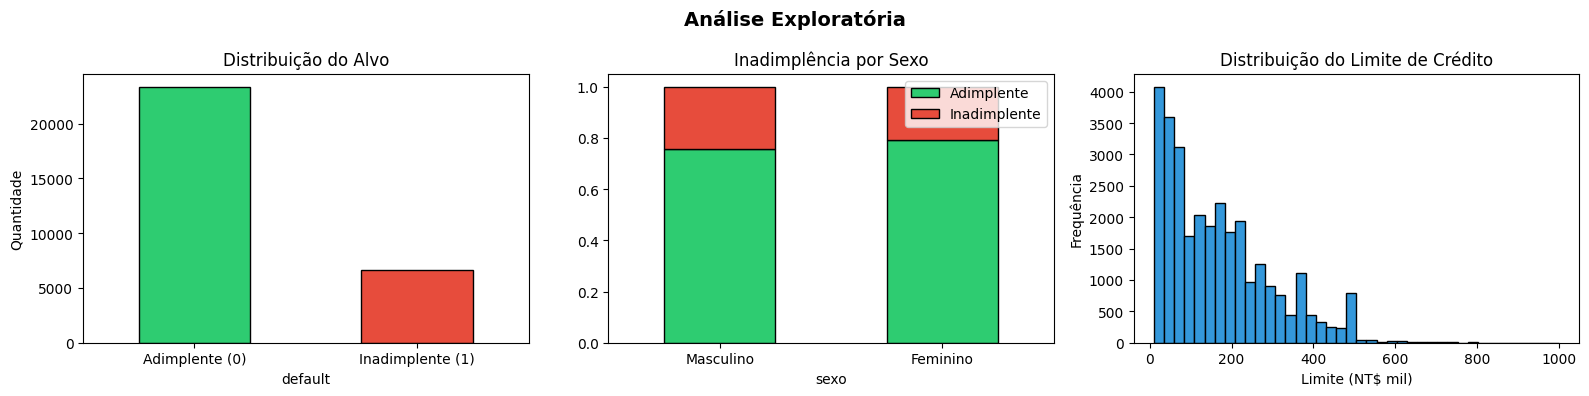

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Análise Exploratória", fontsize=14, fontweight="bold")

df[TARGET].value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Distribuição do Alvo")
axes[0].set_xticklabels(["Adimplente (0)", "Inadimplente (1)"], rotation=0)
axes[0].set_ylabel("Quantidade")

pd.crosstab(df["sexo"], df[TARGET], normalize="index").plot.bar(
    ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="black", stacked=True
)
axes[1].set_title("Inadimplência por Sexo")
axes[1].set_xticklabels(["Masculino", "Feminino"], rotation=0)
axes[1].legend(["Adimplente", "Inadimplente"])

axes[2].hist(df["limite_credito"] / 1000, bins=40, color="#3498db", edgecolor="black")
axes[2].set_title("Distribuição do Limite de Crédito")
axes[2].set_xlabel("Limite (NT$ mil)")
axes[2].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


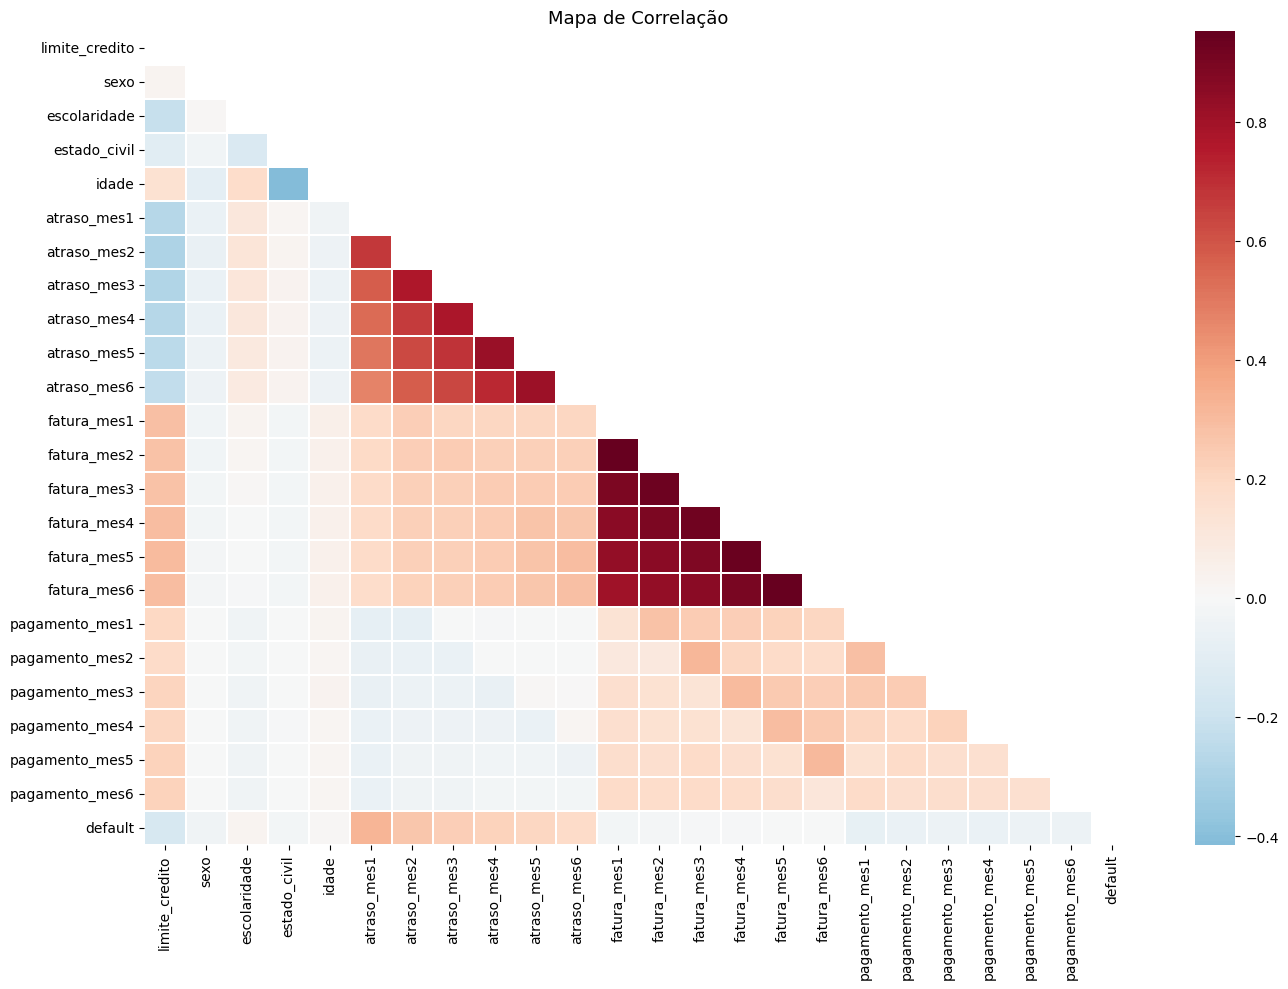

In [ ]:
plt.figure(figsize=(14, 10))
corr = df.drop(columns=["ID"], errors="ignore").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, linewidths=0.3, annot=False)
plt.title("Mapa de Correlação", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Pré-processamento
- Remove coluna `ID`
- Corrige inconsistências em `escolaridade` e `estado_civil`
- Divisão estratificada **70/15/15** (treino / validação / teste)
- Balanceamento com **SMOTE**
- Normalização com **StandardScaler**

In [ ]:
df = df.drop(columns=["ID"], errors="ignore")

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Corrigir valores fora da escala
X["escolaridade"] = X["escolaridade"].replace({0: 4, 5: 4, 6: 4})
X["estado_civil"]  = X["estado_civil"].replace({0: 3})

# Divisão 70/15/15: treino / validação / teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f"Treino: {X_train.shape[0]} | Validação: {X_val.shape[0]} | Teste: {X_test.shape[0]}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Após SMOTE — adimplentes: {(y_train_bal==0).sum()} | inadimplentes: {(y_train_bal==1).sum()}")

scaler = StandardScaler()
_ = scaler.fit_transform(X_train_bal)
print("Normalização concluída.")

Treino: 21000 | Validação: 4500 | Teste: 4500
Após SMOTE — adimplentes: 16355 | inadimplentes: 16355
Normalização concluída.


## 5. Engenharia de Atributos
Novas features criadas:
| Feature | Descrição |
|---|---|
| `taxa_utilizacao_credito` | Total de faturas / Limite de crédito |
| `media_pagamentos` | Média dos pagamentos realizados |
| `total_faturas` | Soma total das faturas |
| `razao_pagamento_fatura` | Razão pagamento médio / fatura média |
| `tendencia_fatura` | Variação da fatura (recente - antiga) |
| `maior_atraso` | Máximo de meses em atraso |

In [ ]:
def engineer_features(df_in):
    df_out = df_in.copy()
    bill_cols       = [f"fatura_mes{i}"    for i in range(1, 7)]
    pay_cols        = [f"pagamento_mes{i}" for i in range(1, 7)]
    pay_status_cols = [f"atraso_mes{i}"    for i in range(1, 7)]

    total_bill = df_out[bill_cols].sum(axis=1).replace(0, np.nan)
    df_out["taxa_utilizacao_credito"]    = total_bill / df_out["limite_credito"]
    df_out["media_pagamentos"]   = df_out[pay_cols].mean(axis=1)
    df_out["total_faturas"]    = df_out[bill_cols].sum(axis=1)
    df_out["razao_pagamento_fatura"] = df_out["media_pagamentos"] / (df_out["total_faturas"].replace(0, np.nan) / 6)
    df_out["tendencia_fatura"]    = df_out["fatura_mes1"] - df_out["fatura_mes6"]
    df_out["maior_atraso"]     = df_out[pay_status_cols].max(axis=1)

    return df_out.fillna(0)

X_train_fe = engineer_features(pd.DataFrame(X_train_bal, columns=X.columns))
X_val_fe   = engineer_features(X_val.copy())
X_test_fe  = engineer_features(X_test.copy())

print(f"Features originais: {X_train.shape[1]} → com engenharia: {X_train_fe.shape[1]}")
X_train_fe.head()

Features originais: 23 → com engenharia: 29


,limite_credito,sexo,escolaridade,estado_civil,idade,atraso_mes1,atraso_mes2,atraso_mes3,atraso_mes4,atraso_mes5,...,pagamento_mes3,pagamento_mes4,pagamento_mes5,pagamento_mes6,taxa_utilizacao_credito,media_pagamentos,total_faturas,razao_pagamento_fatura,tendencia_fatura,maior_atraso
0,160000,2,2,2,32,0,0,0,0,0,...,5600,6000,6000,5500,5.83465,5850.000000,933544,0.037599,280,0
1,100000,2,1,2,30,0,0,0,0,2,...,10000,0,2846,1936,2.58279,4963.666667,258279,0.115309,-24205,2
2,80000,1,1,2,29,0,0,0,0,0,...,1556,1600,1600,1600,4.29765,2026.000000,343812,0.035357,30918,0
3,20000,2,2,1,27,0,0,-1,-1,-2,...,0,0,0,0,0.51130,297.666667,10226,0.174653,7286,0
4,50000,2,1,2,30,-2,-2,-2,-2,-2,...,0,0,0,0,0.04140,345.000000,2070,1.000000,0,-2


In [ ]:
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_val_fe_scaled   = scaler_fe.transform(X_val_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)
print("Normalização pós-engenharia concluída.")

Normalização pós-engenharia concluída.


## 6. Treinamento dos Modelos
Todos os modelos treinados com o **mesmo pipeline** (dados balanceados via SMOTE + StandardScaler):
- **Regressão Logística** — modelo linear de referência (baseline)
- **Random Forest** — ensemble de árvores de decisão
- **XGBoost** — gradient boosting otimizado

Otimização via **Cross-Validation (5-fold estratificado)**.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Regressão Logística (SMOTE) ──
lr = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_fe_scaled, y_train_bal)
cv_lr = cross_val_score(lr, X_train_fe_scaled, y_train_bal, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC (Regressão Logística): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

# ── Random Forest (SMOTE) ──
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train_fe_scaled, y_train_bal)
cv_rf = cross_val_score(rf, X_train_fe_scaled, y_train_bal, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC (Random Forest):        {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

# ── XGBoost (SMOTE — mesmo pipeline de LR e RF) ──
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(
    X_train_fe_scaled, y_train_bal,
    eval_set=[(X_val_fe_scaled, y_val)],
    verbose=False,
)
cv_xgb = cross_val_score(xgb_model, X_train_fe_scaled, y_train_bal, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC (XGBoost):              {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")


CV ROC-AUC (Regressão Logística): 0.7965 ± 0.0046
CV ROC-AUC (Random Forest):        0.8852 ± 0.0049
CV ROC-AUC (XGBoost):              0.9169 ± 0.0036


## 7. Avaliação e Comparação dos Modelos
Métricas avaliadas: **Acuracia, Precisao, Revocação, F1-Score e Auc-Roc**

In [ ]:
def avaliar_modelo(nome, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    metricas = {
        "Modelo"           : nome,
        "Acurácia"         : accuracy_score(y_te, y_pred),
        "Precisão"         : precision_score(y_te, y_pred),
        "Revocação"        : recall_score(y_te, y_pred),
        "F1-Score"         : f1_score(y_te, y_pred),
        "AUC-ROC"          : roc_auc_score(y_te, y_prob),
    }
    print(f"\n─── {nome} ───")
    print(classification_report(y_te, y_pred, target_names=["Adimplente", "Inadimplente"]))
    return metricas, y_prob

metricas_lr, prob_lr = avaliar_modelo("Regressão Logística", lr, X_test_fe_scaled, y_test)
metricas_rf, prob_rf = avaliar_modelo("Random Forest",       rf, X_test_fe_scaled, y_test)
metricas_xgb, prob_xgb = avaliar_modelo("XGBoost", xgb_model, X_test_fe_scaled, y_test)

resultados = pd.DataFrame([metricas_lr, metricas_rf, metricas_xgb]).set_index("Modelo")
resultados


─── Regressão Logística ───
              precision    recall  f1-score   support

  Adimplente       0.87      0.73      0.80      3504
Inadimplente       0.39      0.60      0.48       996

    accuracy                           0.71      4500
   macro avg       0.63      0.67      0.64      4500
weighted avg       0.76      0.71      0.72      4500


─── Random Forest ───
              precision    recall  f1-score   support

  Adimplente       0.87      0.84      0.86      3504
Inadimplente       0.50      0.57      0.53       996

    accuracy                           0.78      4500
   macro avg       0.69      0.70      0.69      4500
weighted avg       0.79      0.78      0.78      4500


─── XGBoost ───
              precision    recall  f1-score   support

  Adimplente       0.86      0.86      0.86      3504
Inadimplente       0.50      0.50      0.50       996

    accuracy                           0.78      4500
   macro avg       0.68      0.68      0.68      4500
weigh

,Acurácia,Precisão,Revocação,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.705556,0.392554,0.603414,0.475663,0.711396
Random Forest,0.778667,0.500000,0.565261,0.530631,0.776877
XGBoost,0.778889,0.500506,0.496988,0.498741,0.760157


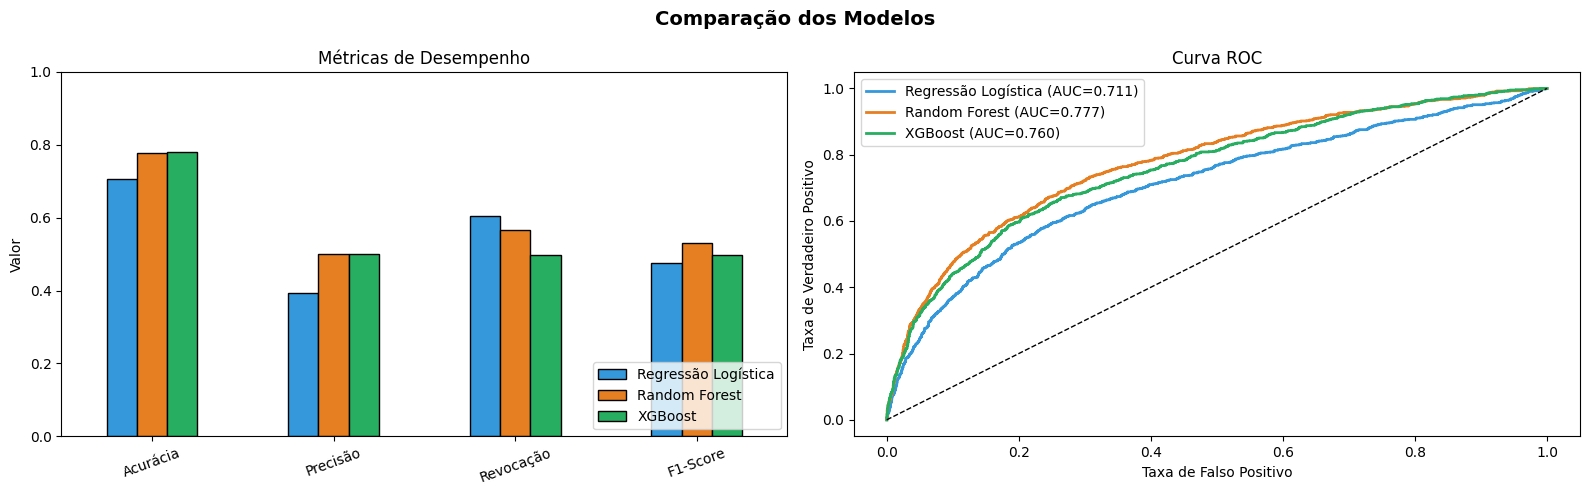

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) # Increased figsize to accommodate 3 models in legend and bar plots
fig.suptitle("Comparação dos Modelos", fontsize=14, fontweight="bold")

metricas_plot = resultados.drop(columns=["AUC-ROC"])
metricas_plot.T.plot.bar(ax=axes[0], color=["#3498db", "#e67e22", "#27ae60"], edgecolor="black")
axes[0].set_title("Métricas de Desempenho")
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(metricas_plot.columns, rotation=20)
axes[0].legend(loc="lower right")
axes[0].set_ylabel("Valor")

for nome, probs, cor in [("Regressão Logística", prob_lr, "#3498db"),
                          ("Random Forest",        prob_rf, "#e67e22"),
                          ("XGBoost",             prob_xgb, "#27ae60")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})", color=cor, lw=2)

axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("Taxa de Falso Positivo")
axes[1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[1].legend()

plt.tight_layout()
plt.show()

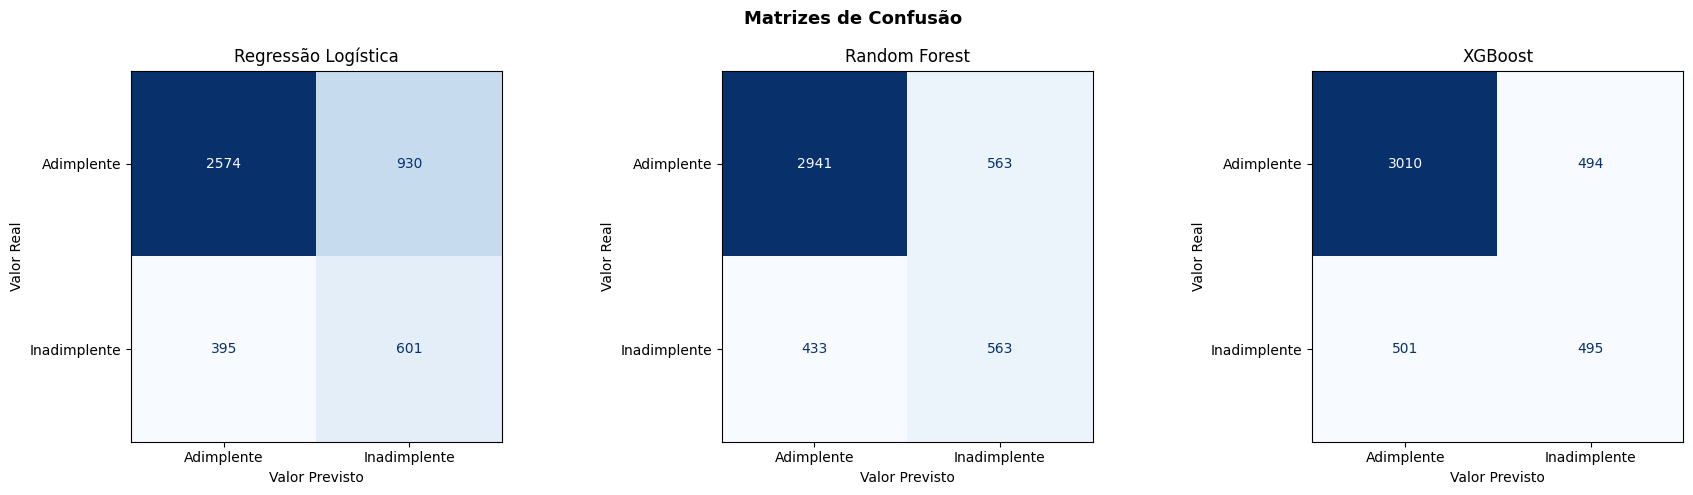

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrizes de Confusão", fontsize=13, fontweight="bold")
for ax, (nome, modelo) in zip(axes, [("Regressão Logística", lr), ("Random Forest", rf), ("XGBoost", xgb_model)]):
    cm = confusion_matrix(y_test, modelo.predict(X_test_fe_scaled))
    ConfusionMatrixDisplay(cm, display_labels=["Adimplente", "Inadimplente"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(nome)
    ax.set_xlabel("Valor Previsto")
    ax.set_ylabel("Valor Real")
plt.tight_layout()
plt.show()

## 8. Interpretabilidade dos Modelos

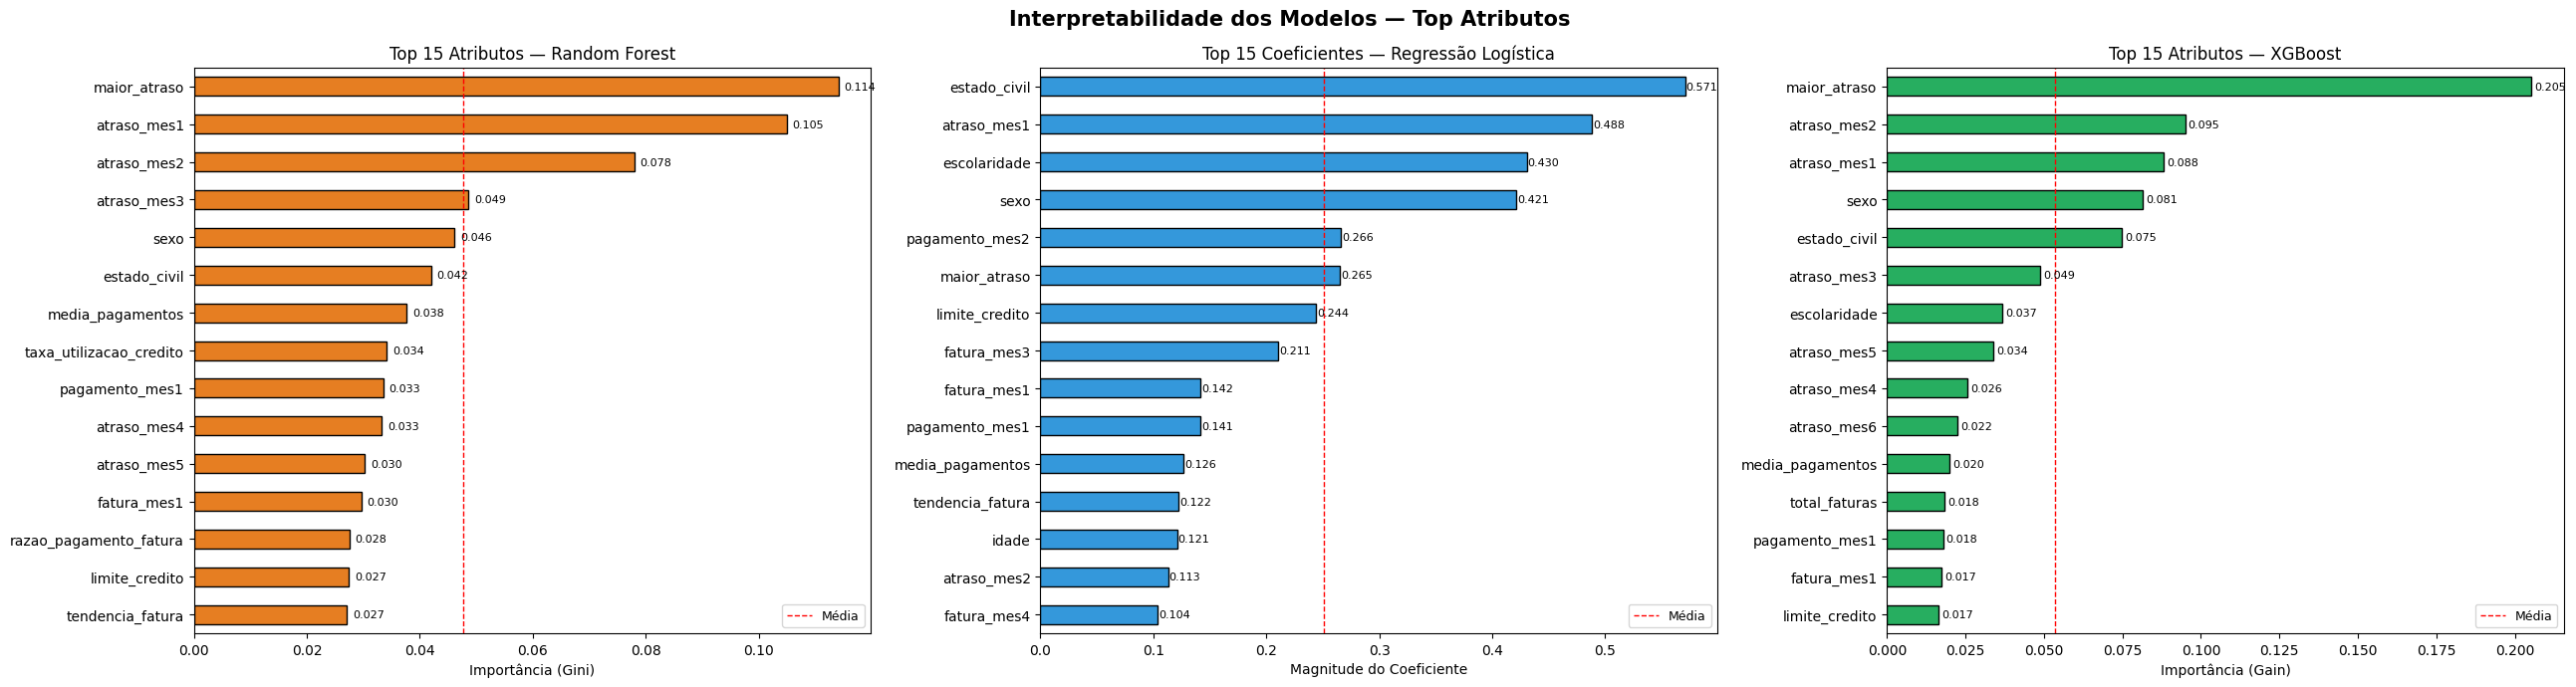

In [ ]:
feat_names   = list(X_train_fe.columns)
top_n = 15

fig, axes = plt.subplots(1, 3, figsize=(26, 7))
fig.suptitle("Interpretabilidade dos Modelos — Top Atributos", fontsize=15, fontweight="bold")

# Random Forest
imp_rf  = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
imp_top = imp_rf.head(top_n).sort_values()
imp_top.plot.barh(ax=axes[0], color="#e67e22", edgecolor="black")
axes[0].set_title(f"Top {top_n} Atributos — Random Forest", fontsize=12)
axes[0].set_xlabel("Importância (Gini)", fontsize=10)
axes[0].axvline(imp_top.mean(), color="red", linestyle="--", linewidth=1, label="Média")
axes[0].legend(fontsize=9)
for i, v in enumerate(imp_top):
    axes[0].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

# Regressão Logística
coefs    = pd.Series(np.abs(lr.coef_[0]), index=feat_names).sort_values(ascending=False)
coef_top = coefs.head(top_n).sort_values()
coef_top.plot.barh(ax=axes[1], color="#3498db", edgecolor="black")
axes[1].set_title(f"Top {top_n} Coeficientes — Regressão Logística", fontsize=12)
axes[1].set_xlabel("Magnitude do Coeficiente", fontsize=10)
axes[1].axvline(coef_top.mean(), color="red", linestyle="--", linewidth=1, label="Média")
axes[1].legend(fontsize=9)
for i, v in enumerate(coef_top):
    axes[1].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

# XGBoost
imp_xgb  = pd.Series(xgb_model.feature_importances_, index=feat_names).sort_values(ascending=False)
xgb_top  = imp_xgb.head(top_n).sort_values()
xgb_top.plot.barh(ax=axes[2], color="#27ae60", edgecolor="black")
axes[2].set_title(f"Top {top_n} Atributos — XGBoost", fontsize=12)
axes[2].set_xlabel("Importância (Gain)", fontsize=10)
axes[2].axvline(xgb_top.mean(), color="red", linestyle="--", linewidth=1, label="Média")
axes[2].legend(fontsize=9)
for i, v in enumerate(xgb_top):
    axes[2].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 9. Comparativo Final entre os Modelos

Consolidação de todas as métricas e análise visual comparativa entre  
**Regressão Logística**, **Random Forest** e **XGBoost**.


Métrica             Regressão Logística   Random Forest         XGBoost
----------------------------------------------------------------------
Acurácia                    0.7056          0.7787          0.7789 ★
Precisão                    0.3926          0.5000          0.5005 ★
Revocação                   0.6034 ★        0.5653          0.4970  
F1-Score                    0.4757          0.5306 ★        0.4987  
AUC-ROC                     0.7114          0.7769 ★        0.7602  
CV AUC (μ)                  0.7965          0.8852          0.9169 ★
CV AUC (σ)                  0.0046          0.0049          0.0036 ★
★ = melhor valor na métrica


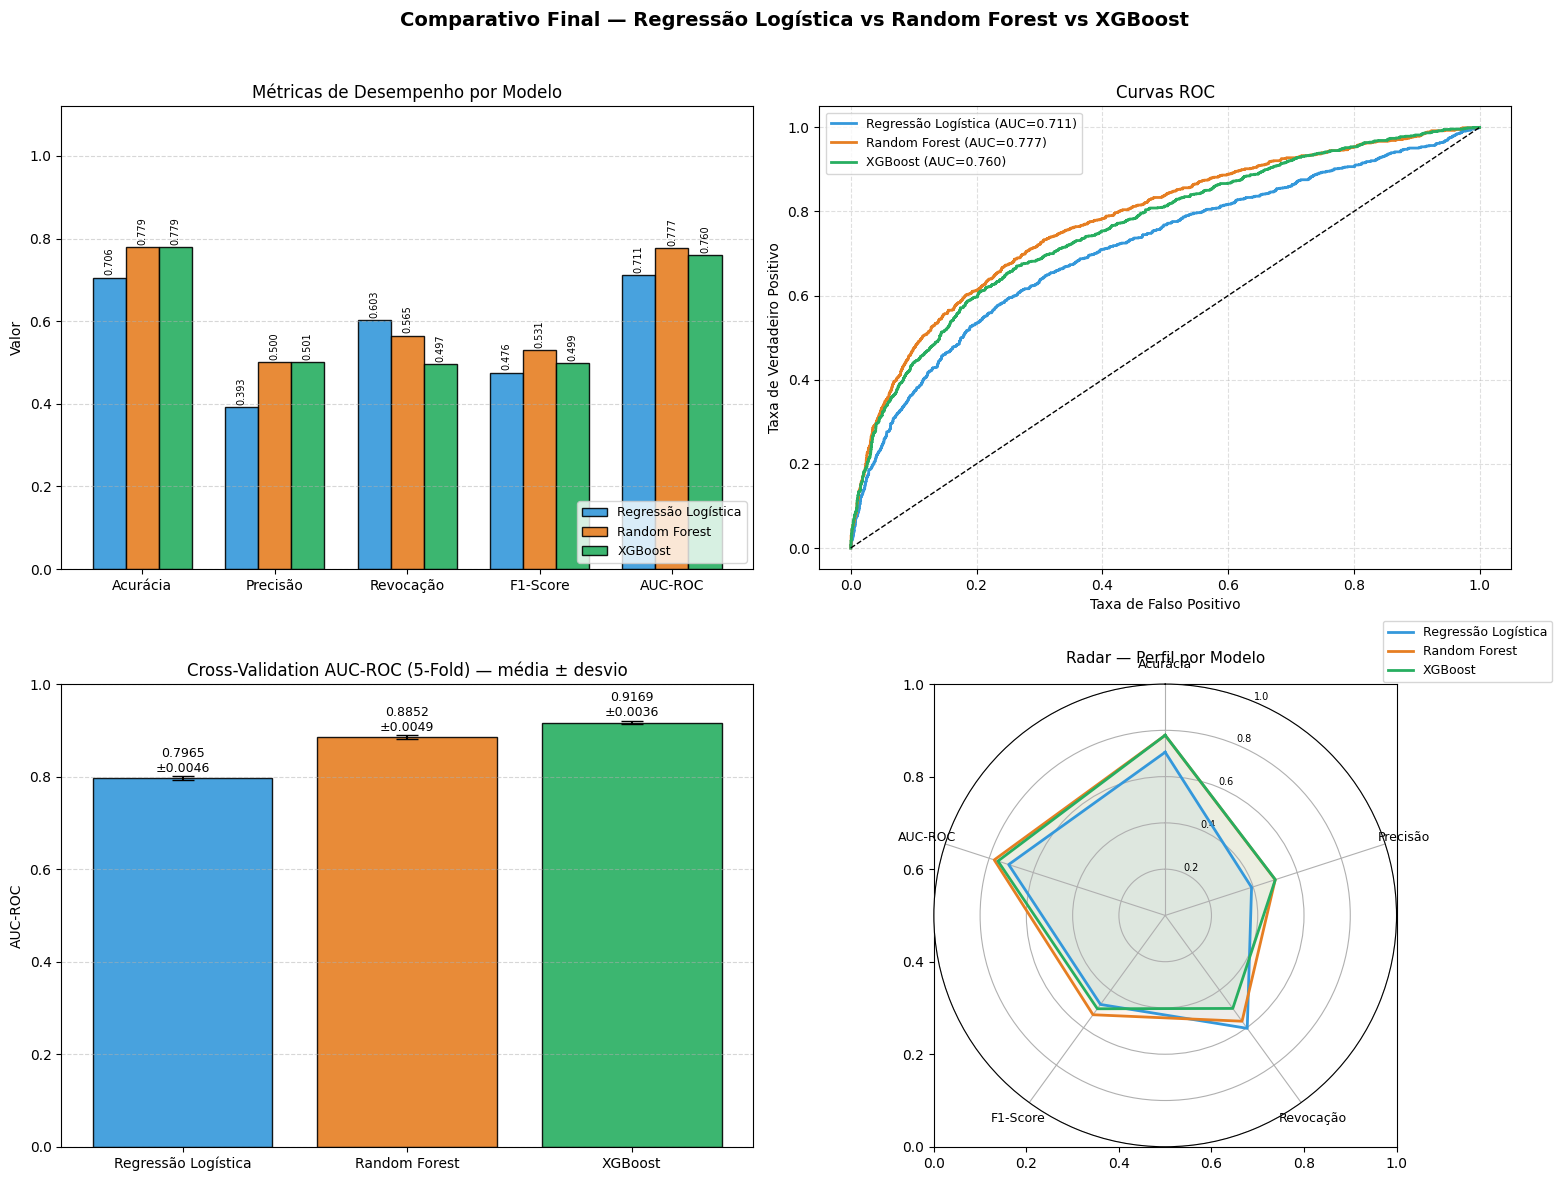

In [ ]:
CORES = {
    "Regressão Logística": "#3498db",
    "Random Forest"      : "#e67e22",
    "XGBoost"            : "#27ae60",
}

# ── Tabela comparativa ──
print("=" * 70)
print(f"{'Métrica':<20}", end="")
for m in CORES:
    print(f"{m:>16}", end="")
print()
print("-" * 70)

metricas_rows = {
    "Acurácia"  : [metricas_lr["Acurácia"],  metricas_rf["Acurácia"],  metricas_xgb["Acurácia"]],
    "Precisão"  : [metricas_lr["Precisão"],  metricas_rf["Precisão"],  metricas_xgb["Precisão"]],
    "Revocação" : [metricas_lr["Revocação"], metricas_rf["Revocação"], metricas_xgb["Revocação"]],
    "F1-Score"  : [metricas_lr["F1-Score"],  metricas_rf["F1-Score"],  metricas_xgb["F1-Score"]],
    "AUC-ROC"   : [metricas_lr["AUC-ROC"],   metricas_rf["AUC-ROC"],   metricas_xgb["AUC-ROC"]],
    "CV AUC (μ)": [cv_lr.mean(),             cv_rf.mean(),             cv_xgb.mean()],
    "CV AUC (σ)": [cv_lr.std(),              cv_rf.std(),              cv_xgb.std()],
}

for nome_m, vals in metricas_rows.items():
    melhor = max(vals) if nome_m != "CV AUC (σ)" else min(vals)
    print(f"{nome_m:<20}", end="")
    for v in vals:
        marker = " ★" if abs(v - melhor) < 1e-9 else "  "
        print(f"{v:>14.4f}{marker}", end="")
    print()

print("=" * 70)
print("★ = melhor valor na métrica")

# ── Figura comparativa ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparativo Final — Regressão Logística vs Random Forest vs XGBoost",
             fontsize=14, fontweight="bold")

modelos  = list(CORES.keys())
cores    = list(CORES.values())

# 1) Barras por métrica
metricas_bar = ["Acurácia", "Precisão", "Revocação", "F1-Score", "AUC-ROC"]
x = np.arange(len(metricas_bar))
w = 0.25
for j, (mod, cor) in enumerate(CORES.items()):
    vals = [metricas_rows[m][j] for m in metricas_bar]
    bars = axes[0, 0].bar(x + j * w, vals, w, label=mod, color=cor, edgecolor="black", alpha=0.9)
    for bar, v in zip(bars, vals):
        axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)
axes[0, 0].set_xticks(x + w)
axes[0, 0].set_xticklabels(metricas_bar)
axes[0, 0].set_ylim(0, 1.12)
axes[0, 0].set_title("Métricas de Desempenho por Modelo")
axes[0, 0].set_ylabel("Valor")
axes[0, 0].legend(loc="lower right", fontsize=9)
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# 2) Curvas ROC
for (nome, probs, cor) in [("Regressão Logística", prob_lr,  "#3498db"),
                             ("Random Forest",       prob_rf,  "#e67e22"),
                             ("XGBoost",             prob_xgb, "#27ae60")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0, 1].plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})", color=cor, lw=2)
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1)
axes[0, 1].set_title("Curvas ROC")
axes[0, 1].set_xlabel("Taxa de Falso Positivo")
axes[0, 1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(linestyle="--", alpha=0.4)

# 3) Cross-Validation AUC (média ± desvio)
cv_means = [cv_lr.mean(), cv_rf.mean(), cv_xgb.mean()]
cv_stds  = [cv_lr.std(),  cv_rf.std(),  cv_xgb.std()]
bars = axes[1, 0].bar(modelos, cv_means, color=cores, edgecolor="black",
                       yerr=cv_stds, capsize=8, alpha=0.9)
for bar, m, s in zip(bars, cv_means, cv_stds):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + s + 0.003,
                    f"{m:.4f}\n±{s:.4f}", ha="center", va="bottom", fontsize=9)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("Cross-Validation AUC-ROC (5-Fold) — média ± desvio")
axes[1, 0].set_ylabel("AUC-ROC")
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# 4) Radar / spider-like: métricas em radar
from matplotlib.patches import FancyArrowPatch
categorias = ["Acurácia", "Precisão", "Revocação", "F1-Score", "AUC-ROC"]
N = len(categorias)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax_r = axes[1, 1]
ax_r.set_aspect("equal")
ax_r = fig.add_subplot(2, 2, 4, polar=True)
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categorias, fontsize=9)
ax_r.set_ylim(0, 1)
ax_r.yaxis.set_tick_params(labelsize=7)

for j, (mod, cor) in enumerate(CORES.items()):
    vals = [metricas_rows[m][j] for m in categorias] + [metricas_rows[categorias[0]][j]]
    ax_r.plot(angles, vals, color=cor, linewidth=2, label=mod)
    ax_r.fill(angles, vals, color=cor, alpha=0.08)

ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_r.set_title("Radar — Perfil por Modelo", fontsize=11, pad=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 10. Estratégia de Definição de Limite de Crédito
Converte a probabilidade predita em categorias de risco e ajusta o limite aprovado:

| Probabilidade | Categoria | Fator |
|---|---|---|
| < 15% | Baixo Risco | 100% |
| 15% – 30% | Risco Moderado | 75% |
| 30% – 50% | Risco Elevado | 50% |
| ≥ 50% | Risco Crítico | Recusado |

In [ ]:
def calcular_limite(prob_inadimplencia: float, limite_solicitado: float,
                    limite_maximo: float = 500_000.0) -> dict:
    if prob_inadimplencia < 0.15:
        fator, categoria = 1.00, "BAIXO RISCO"
    elif prob_inadimplencia < 0.30:
        fator, categoria = 0.75, "RISCO MODERADO"
    elif prob_inadimplencia < 0.50:
        fator, categoria = 0.50, "RISCO ELEVADO"
    else:
        fator, categoria = 0.00, "RISCO CRÍTICO — RECUSADO"

    return {
        "prob_inadimplencia": round(prob_inadimplencia, 4),
        "categoria_risco"   : categoria,
        "limite_solicitado" : limite_solicitado,
        "limite_aprovado"   : round(min(limite_solicitado * fator, limite_maximo), 2),
    }

amostras    = X_test_fe_scaled[:5]
limites_sol = X_test.iloc[:5]["limite_credito"].values
probs_rf    = rf.predict_proba(amostras)[:, 1]

resultados_limite = [calcular_limite(prob, float(lim))
                     for prob, lim in zip(probs_rf, limites_sol)]

pd.DataFrame(resultados_limite)

,prob_inadimplencia,categoria_risco,limite_solicitado,limite_aprovado
0,0.1604,RISCO MODERADO,80000.0,60000.0
1,0.1527,RISCO MODERADO,200000.0,150000.0
2,0.6529,RISCO CRÍTICO — RECUSADO,360000.0,0.0
3,0.5514,RISCO CRÍTICO — RECUSADO,60000.0,0.0
4,0.6770,RISCO CRÍTICO — RECUSADO,30000.0,0.0


## 11. Resultados


In [ ]:
resultados

,Acurácia,Precisão,Revocação,F1-Score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.705556,0.392554,0.603414,0.475663,0.711396
Random Forest,0.778667,0.500000,0.565261,0.530631,0.776877
XGBoost,0.778889,0.500506,0.496988,0.498741,0.760157


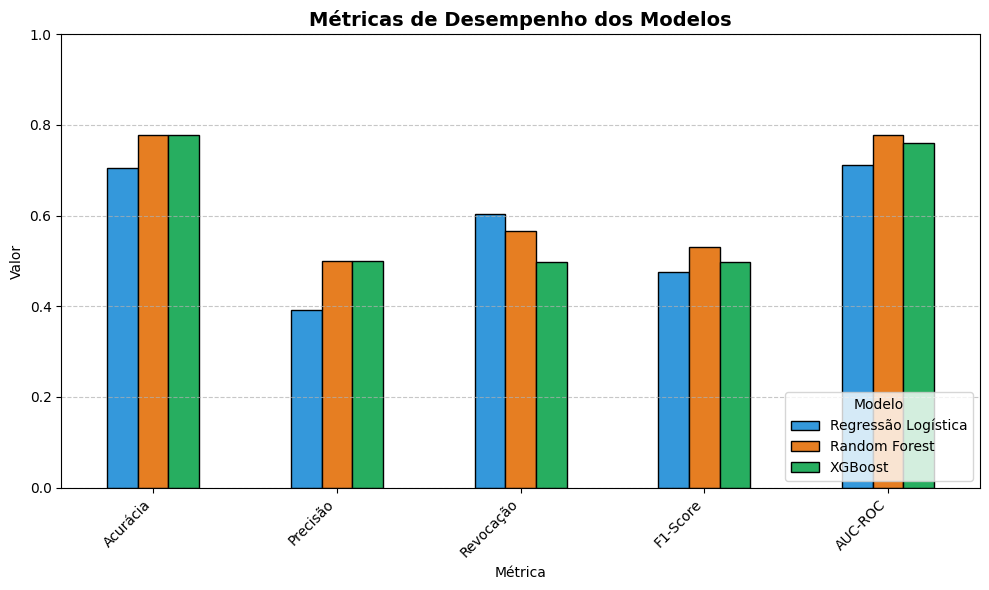

In [ ]:

fig = plt.figure(figsize=(10, 6))
resultados.T.plot.bar(ax=plt.gca(), color=["#3498db", "#e67e22", "#27ae60"], edgecolor="black")
plt.title("Métricas de Desempenho dos Modelos", fontsize=14, fontweight="bold")
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Modelo", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()